# Stage 1 - Data loading 


In [1]:
import pandas as pd


In [2]:
def load_fd001(path):
    cols = ["unit", "cycle", "op1", "op2", "op3"] + [f"sensor{i}" for i in range (1,22)]
    df = pd.read_csv(path, sep=r"\s+", header = None, names = cols) 
    return df 

train = load_fd001("../data/raw/train_FD001.txt")
test = load_fd001("../data/raw/test_FD001.txt")
train.head()



,unit,cycle,op1,op2,op3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor12,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [3]:
print(train.shape)
print(train["unit"].nunique())
print(train.isna().sum().sum())


(20631, 26)
100
0


# Stage 2 - Data processing and filtering

In [4]:
# we only worry about the sensor data
sensor_cols = [c for c in train.columns if "sensor" in c]
train[sensor_cols].std().sort_values()

sensor1     0.000000e+00
sensor19    0.000000e+00
sensor18    0.000000e+00
sensor10    0.000000e+00
sensor16    1.387812e-17
sensor5     1.776400e-15
sensor6     1.388985e-03
sensor15    3.750504e-02
sensor8     7.098548e-02
sensor13    7.191892e-02
sensor21    1.082509e-01
sensor20    1.807464e-01
sensor11    2.670874e-01
sensor2     5.000533e-01
sensor12    7.375534e-01
sensor7     8.850923e-01
sensor17    1.548763e+00
sensor3     6.131150e+00
sensor4     9.000605e+00
sensor14    1.907618e+01
sensor9     2.208288e+01
dtype: float64

In [5]:
# we eliminate the aproximately constant sensors as they do not provide useful information
constant_sensors = [c for c in sensor_cols if train[c].std()<0.0001]
print(constant_sensors)
train_clean = train.drop(columns = constant_sensors)
test_clean = test.drop(columns = [c for c in constant_sensors if  c in test.columns])
print (train_clean.shape)

['sensor1', 'sensor5', 'sensor10', 'sensor16', 'sensor18', 'sensor19']
(20631, 20)


# Stage 3 - RUL Target creation

In [6]:
# RUL setting
def add_rul(df):
    max_cycle= df.groupby("unit")["cycle"].transform("max")
    df["RUL"] = max_cycle -df["cycle"] 
    return df 

train_clean = add_rul(train_clean)
train_clean[["unit","cycle","RUL"]].head(10)


,unit,cycle,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187
5,1,6,186
6,1,7,185
7,1,8,184
8,1,9,183
9,1,10,182


In [7]:
train_clean.groupby("unit")["RUL"].max().describe()


count    100.000000
mean     205.310000
std       46.342749
min      127.000000
25%      176.000000
50%      198.000000
75%      228.250000
max      361.000000
Name: RUL, dtype: float64

In [8]:
import matplotlib.pyplot as plt 


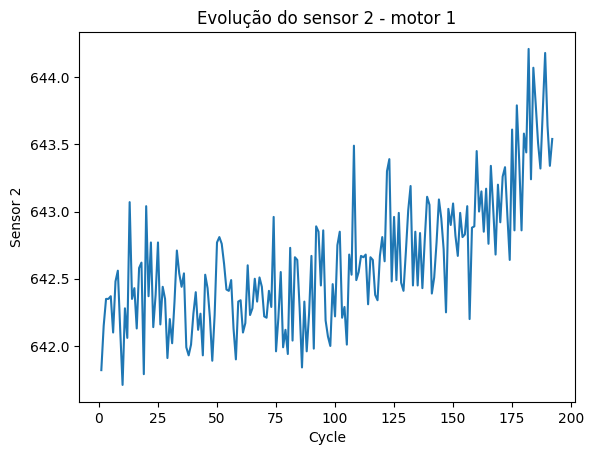

In [9]:

engine1 = train_clean[train_clean["unit"]==1]
plt.plot(engine1["cycle"], engine1["sensor2"])
plt.xlabel("Cycle")
plt.ylabel("Sensor 2")
plt.title ("Evolução do sensor 2 - motor 1")
plt.show()

In [10]:
#Trying to predict the sensors behaviour many cycles prior will only cause noise 
train_clean["RUL"] = train_clean["RUL"].clip(upper=125)
train_clean["RUL"].describe()


count    20631.000000
mean        86.829286
std         41.673699
min          0.000000
25%         51.000000
50%        103.000000
75%        125.000000
max        125.000000
Name: RUL, dtype: float64

# Stage 4 - Baseline (RandomForest)


In [11]:

from sklearn.model_selection import train_test_split 
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error 
import numpy as np 

feature_cols = [c for c in train_clean.columns if c not in ["unit", "cycle", "RUL"]]
X = train_clean[feature_cols]
Y = train_clean["RUL"]
print(feature_cols)
print(X.shape, Y.shape)


['op1', 'op2', 'op3', 'sensor2', 'sensor3', 'sensor4', 'sensor6', 'sensor7', 'sensor8', 'sensor9', 'sensor11', 'sensor12', 'sensor13', 'sensor14', 'sensor15', 'sensor17', 'sensor20', 'sensor21']
(20631, 18) (20631,)


In [12]:
X.head(5)

,op1,op2,op3,sensor2,sensor3,sensor4,sensor6,sensor7,sensor8,sensor9,sensor11,sensor12,sensor13,sensor14,sensor15,sensor17,sensor20,sensor21
0,-0.0007,-0.0004,100.0,641.82,1589.70,1400.60,21.61,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190
1,0.0019,-0.0003,100.0,642.15,1591.82,1403.14,21.61,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236
2,-0.0043,0.0003,100.0,642.35,1587.99,1404.20,21.61,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442
3,0.0007,0.0000,100.0,642.35,1582.79,1401.87,21.61,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739
4,-0.0019,-0.0002,100.0,642.37,1582.85,1406.22,21.61,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044


In [13]:
# Training split
X_train, X_val, Y_train, Y_val = train_test_split(X,Y,test_size = 0.2, random_state=42)
print (X_train.shape, X_val.shape)

(16504, 18) (4127, 18)


In [14]:
# Training loop 
model = RandomForestRegressor(n_estimators = 100, random_state=42) 
model.fit (X_train, Y_train)


RandomForestRegressor(random_state=42)

In [15]:
#Error
preds = model.predict(X_val)
rmse = np.sqrt(mean_squared_error(Y_val, preds))
mae = mean_absolute_error(Y_val, preds)
print(f"RMSE = {rmse:.2f}")
print(f"MAE: {mae:.2f}")


RMSE = 18.77
MAE: 13.57


In [ ]:
# The most frequently used sensors by the trees

import pandas as pd

importances = pd.Series(model.feature_importances_, index=feature_cols)
importances.sort_values(ascending=False).head(10)

sensor11    0.562439
sensor9     0.131422
sensor4     0.077239
sensor12    0.047182
sensor7     0.025108
sensor14    0.022886
sensor15    0.019845
sensor21    0.017974
sensor2     0.016130
sensor3     0.014698
dtype: float64

In [ ]:
# How much the sensors affect RUL
train_clean[feature_cols + ['RUL']].corr()['RUL'].sort_values()

sensor11   -0.775230
sensor4    -0.757157
sensor15   -0.720858
sensor17   -0.680829
sensor2    -0.678458
sensor3    -0.655030
sensor8    -0.624568
sensor13   -0.624034
sensor9    -0.462151
sensor14   -0.369753
sensor6    -0.108289
op2        -0.007091
op1        -0.005556
sensor20    0.704626
sensor21    0.707334
sensor7     0.733021
sensor12    0.748870
RUL         1.000000
op3              NaN
Name: RUL, dtype: float64

# Stage 5 - Feature Engineering


In [25]:
sensor_cols_final = [c for c in feature_cols if "sensor" in c]
def add_rolling_features(df, sensor_cols, window=5):
    df = df.sort_values(["unit", "cycle"]).copy()
    for col in sensor_cols:
        df[f"{col}_rollmean"] = df.groupby("unit")[col].transform(
            lambda x: x.rolling(window, min_periods=1).mean())
        df[f"{col}_rollstd"] = df.groupby("unit")[col].transform(
            lambda x: x.rolling(window, min_periods=1).std().fillna(0))
    return df
train_fe = add_rolling_features(train_clean, sensor_cols_final) 
train_fe.shape


(20631, 51)

In [26]:
train_fe[["unit", "cycle", "sensor2", "sensor2_rollmean", "sensor2_rollstd"]].head(10)

,unit,cycle,sensor2,sensor2_rollmean,sensor2_rollstd
0,1,1,641.82,641.820000,0.000000
1,1,2,642.15,641.985000,0.233345
2,1,3,642.35,642.106667,0.267644
3,1,4,642.35,642.167500,0.250117
4,1,5,642.37,642.208000,0.234776
5,1,6,642.10,642.264000,0.128374
6,1,7,642.48,642.330000,0.139463
7,1,8,642.56,642.372000,0.174270
8,1,9,642.12,642.326000,0.208519
9,1,10,641.71,642.194000,0.340705
